In [4]:
!pip install tensorflow matplotlib



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

In [6]:
train_dir = r"D:\AI smart manufacturing\visual inspection\NEU-DET\train\images"
val_dir = r"D:\AI smart manufacturing\visual inspection\NEU-DET\validation\images"

In [7]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\AI smart manufacturing\\visual inspection\\NEU-DET\\train\\images'

In [8]:
import os

base_path = r"D:\AI smart manufacturing\visual inspection\NEU-DET"
print(os.listdir(base_path))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\AI smart manufacturing\\visual inspection\\NEU-DET'

In [9]:
train_dir = r"D:\AI smart manufacturing\visual inspection\Dataset\NEU-DET\train\images"
val_dir = r"D:\AI smart manufacturing\visual inspection\Dataset\NEU-DET\validation\images"

In [10]:
import os
print(os.listdir(r"D:\AI smart manufacturing\visual inspection\Dataset\NEU-DET\train"))

['annotations', 'images']


In [11]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.


In [12]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # freeze pretrained layers

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')  # 6 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 200s 4s/step - accuracy: 0.7667 - loss: 0.6618 - val_accuracy: 0.9500 - val_loss: 0.2030
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 832s 19s/step - accuracy: 0.9653 - loss: 0.1419 - val_accuracy: 0.9722 - val_loss: 0.0955
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 374s 3s/step - accuracy: 0.9812 - loss: 0.0824 - val_accuracy: 0.9639 - val_loss: 0.1112
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.9826 - loss: 0.0673 - val_accuracy: 0.9778 - val_loss: 0.0718
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.9854 - loss: 0.0643 - val_accuracy: 0.9889 - val_loss: 0.0667
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.9799 - loss: 0.0562 - val_accuracy: 0.9750 - val_loss: 0.0732
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.9826 - loss: 0.0478 - val_accuracy: 0.9611 - val_loss: 0.0904
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.9924 - loss: 0.0309 - val_accuracy: 0.9722 - 

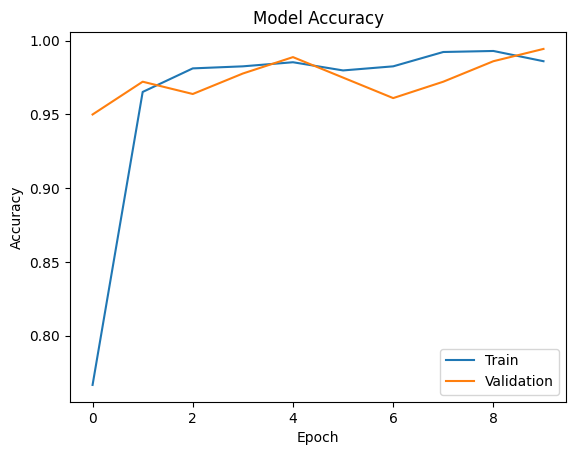

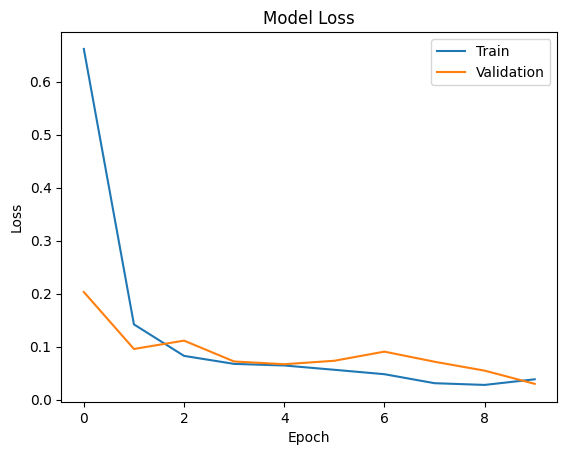

In [14]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [16]:
model.save("neu_defect_classifier.keras")

In [17]:
from tensorflow.keras.models import load_model
model = load_model("neu_defect_classifier.keras")

C:\Users\sripr\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
print(history.history['val_accuracy'])